# Laboratorium 1 — k-ręki bandyta (problem wielo-rękiego złodzieja)

**Cel:** zaimplementować i porównać proste strategie w problemie wielo-rękiego bandyty: eksploracja vs eksploatacja, regret na losowych problemach oraz zachowanie w środowisku niestacjonarnym (dryf prawdopodobieństw).


## Założenia

- Dla **bandytu stacjonarnego** (`TopHitBandit`) każde ramię $a$ daje nagrodę Bernoulliego: sukces (1) z prawdopodobieństwem $p_a$, porażka (0) w przeciwnym razie. Znany jest słownik potencjałów `POTENTIAL_HITS` (fikcyjne tytuły piosenek).
- **Regret** skumulowany do chwili $t$ (w losowych problemach w tym kodzie): $R(t) = t \cdot \max_a p_a - \sum_{i=1}^{t} r_i$ (strata względem zawsze optymalnej decyzji przy tym samym rozkładzie).
- Wariant **niestacjonarny**: prawdopodobieństwa dryfują co krok o $\mathcal{N}(0, \sigma^2)$, obcięte do $[0,1]$ (`NonStationaryTopHitBandit`).


## Pętla problemu: `BanditProblem`

Jeden krok: wybór ramienia, obserwacja nagrody, aktualizacja wewnętrznego stanu ucznia (fragment z `bandits.py`).

```python
def run(self) -> list[float]:
    rewards = []
    for _ in range(self.time_steps):
        arm = self.learner.pick_arm()
        reward = self.bandit.reward(arm)
        self.learner.acknowledge_reward(arm, reward)
        rewards.append(reward)
    return rewards
```

Metryką porównań w eksperymentach jest głównie **średnia skumulowana nagroda** w czasie (lub skumulowany regret).


## Zaimplementowane strategie (skrót)

| Strategia | Idea |
|-----------|------|
| `RandomLearner` | losowy wybór (baseline) |
| `ExploreThenCommitLearner(m)` | $m$ próbek na ramię, potem commit do najlepszego z próby |
| `GreedyLearner(ε)` | z prawd. $\epsilon$ losowe ramię, w przeciwnym razie argmax estymaty $Q$ (średnia próbkowa) |
| `GreedyConstantStep` | jak $\epsilon$-greedy, lecz aktualizacja $Q$ z krokiem stałym $\alpha$ (cenniejsze przy dryfie) |
| `UCB1` | $Q(a) + c\sqrt{\ln t / N(a)}$ |
| `GradientBanditLearner` | softmax na preferencjach $H(a)$, reguła gradientowa z baseline (średnia nagrody) |
| `ThompsonSamplingLearner` | dla Bernoulliego: Beta, wybór po jednej próbce z a posteriori |

In [9]:
# Konfiguracja: import z katalogu laboratorium
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Jupyter / VS Code
%matplotlib inline

# Katalog l1: cwd lub pierwszy przodek, w którym jest bandits.py (works w Jupyter)
L1 = Path.cwd().resolve()
if not (L1 / "bandits.py").is_file():
    for p in L1.parents:
        if (p / "bandits.py").is_file():
            L1 = p
            break
if not (L1 / "bandits.py").is_file():
    raise FileNotFoundError("Nie znaleziono bandits.py — otwórz notatnik z katalogu l1 albo uruchom z cwd=l1")
if str(L1) not in sys.path:
    sys.path.insert(0, str(L1))

import bandits
from bandits import (
    BanditProblem,
    TopHitBandit,
    make_random_bandit,
    NonStationaryTopHitBandit,
    RandomLearner,
    ExploreThenCommitLearner,
    GreedyLearner,
    GreedyConstantStepLearner,
    UCB1,
    GradientBanditLearner,
    ThompsonSamplingLearner,
    POTENTIAL_HITS,
    evaluate_learner,
    evaluate_learner_random_problems,
    plot_random_problems_and_regret,
    run_parameter_study,
    run_nonstationary_experiment,
    TIME_STEPS,
    TRIALS_PER_LEARNER,
    K_ARMS_RANDOM,
)

SEED = 42
np.random.seed(SEED)
print("TIME_STEPS =", TIME_STEPS, "TRIALS =", TRIALS_PER_LEARNER, "K_ARMS =", K_ARMS_RANDOM)


TIME_STEPS = 1000 TRIALS = 50 K_ARMS = 5


## Eksperyment A — ustalone `POTENTIAL_HITS` (stacjonarny)

W każdym z `TRIALS` powtórzeń ten sam `TopHitBandit(POTENTIAL_HITS)`; wykres: uśredniona skumulowana nagroda ± std (`evaluate_learner` w `bandits.py`).

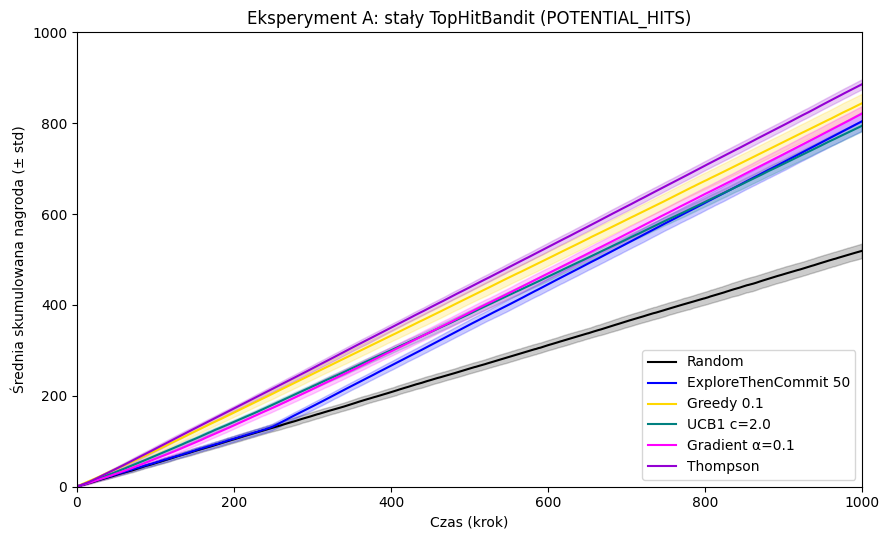

In [10]:
# A: porównanie na stałym problemie
learners_A = [
    RandomLearner(),
    ExploreThenCommitLearner(50, color="blue"),
    GreedyLearner(0.1, color="gold"),
    UCB1(c=2.0, color="teal"),
    GradientBanditLearner(alpha=0.1, color="magenta"),
    ThompsonSamplingLearner(color="darkviolet"),
]
plt.figure(figsize=(9, 5.5))
for L in learners_A:
    evaluate_learner(L)
plt.xlabel("Czas (krok)")
plt.ylabel("Średnia skumulowana nagroda (± std)")
plt.xlim(0, TIME_STEPS)
plt.ylim(0, TIME_STEPS)
plt.title("Eksperyment A: stały TopHitBandit (POTENTIAL_HITS)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
plt.close()

## Eksperyment B — losowe problemy i regret

Dla każdego trialu nowy bandyta `make_random_bandit` (losowe $p_a \sim U(0,1)$). Przy tym samym `seed` te same instancje problemów dla wszystkich uczniów. Dwa panele: skumulowana nagroda i skumulowany regret (`plot_random_problems_and_regret`).

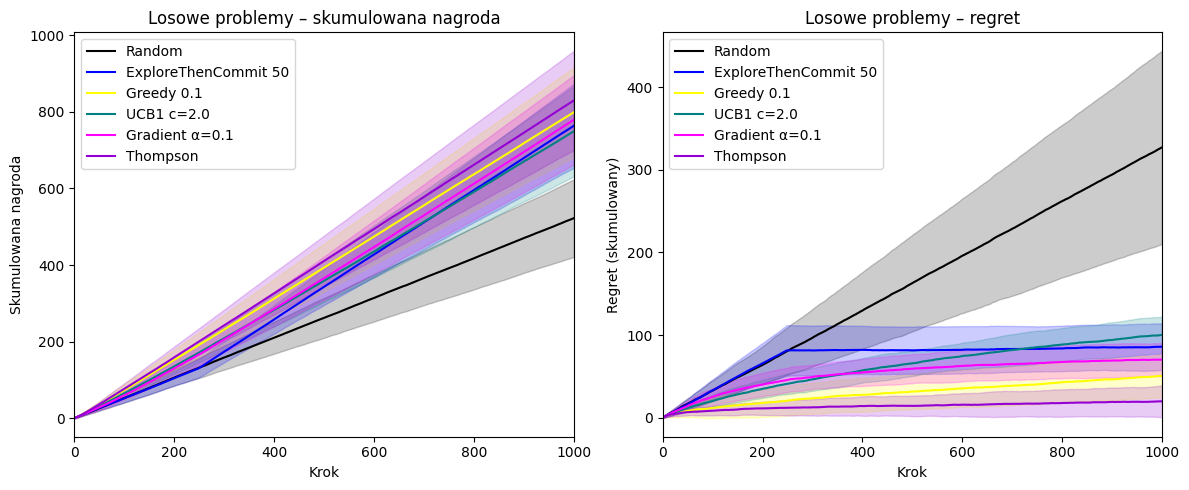

In [11]:
# B: losowe problemy + regret
learners_B = [
    RandomLearner(),
    ExploreThenCommitLearner(50, color="blue"),
    GreedyLearner(0.1, color="yellow"),
    UCB1(c=2.0, color="teal"),
    GradientBanditLearner(alpha=0.1, color="magenta"),
    ThompsonSamplingLearner(color="darkviolet"),
]
plot_random_problems_and_regret(
    learners_B, n_trials=TRIALS_PER_LEARNER, time_steps=TIME_STEPS, k_arms=K_ARMS_RANDOM, seed=SEED
)
plt.close("all")

## Eksperyment C — studium parametryczne

Dla każdej rodziny zmieniany jest meta-parametr ($m$, $\epsilon$, $c$, $\alpha$); Thompson jest jedną krzywą. Funkcja `run_parameter_study` rysuje oddzielną parę wykresów (nagroda, regret) na każdą rodzinę — zgodnie z [bandits.py](bandits.py).

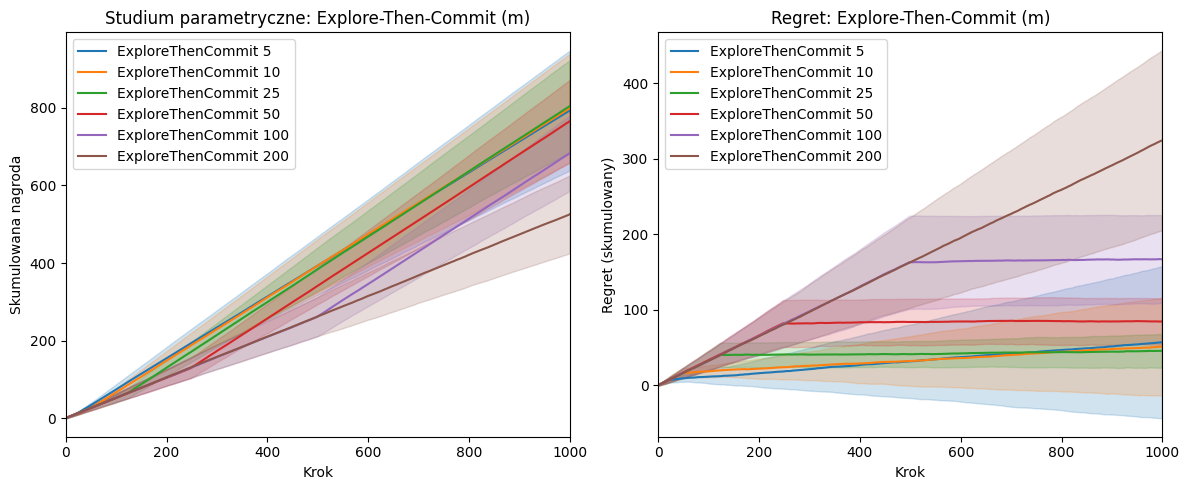

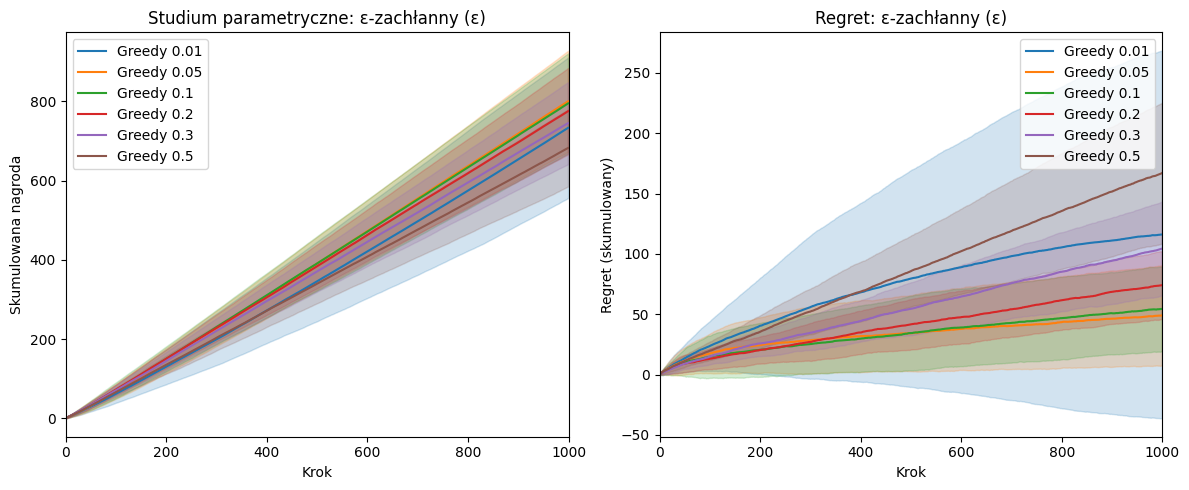

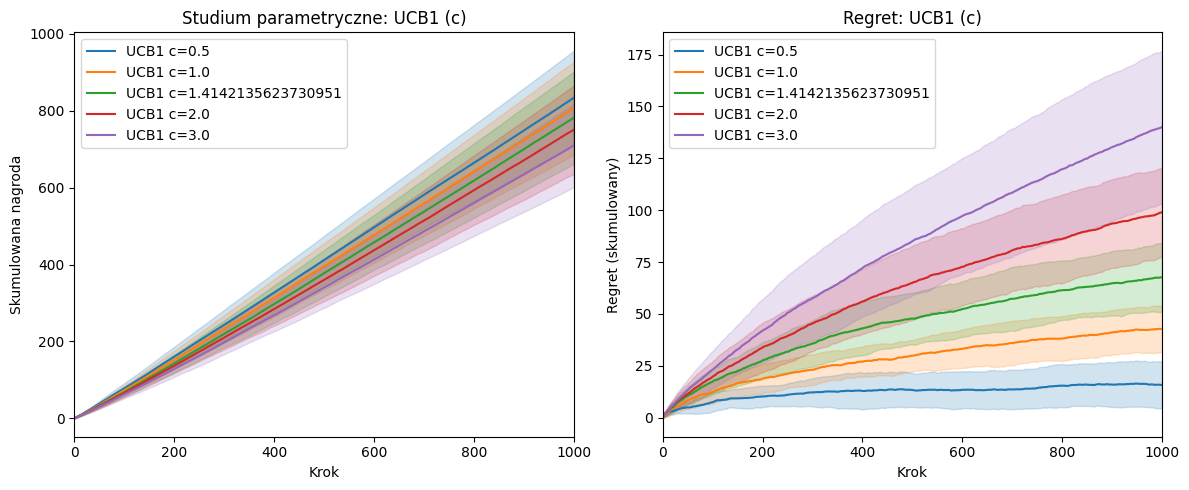

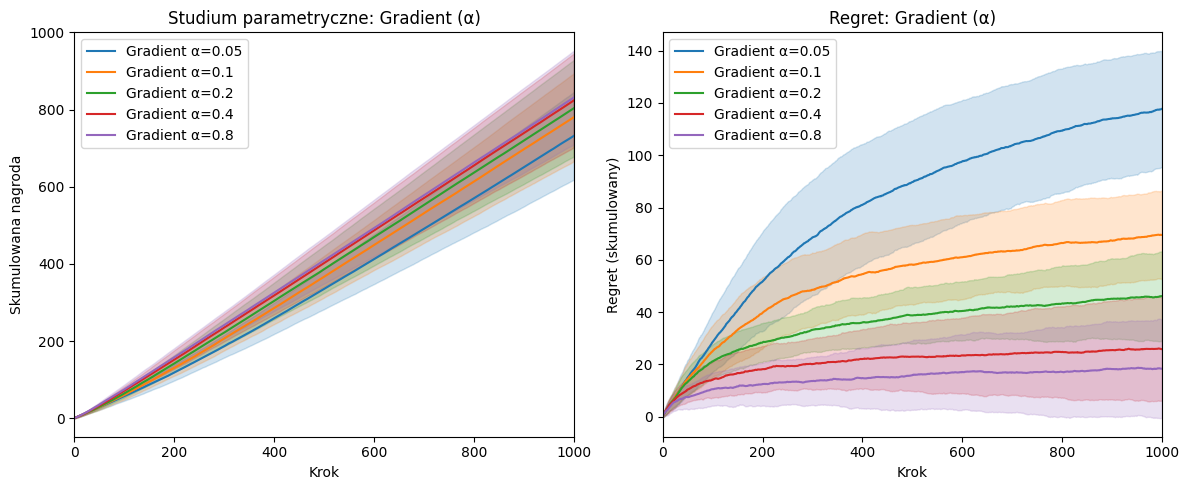

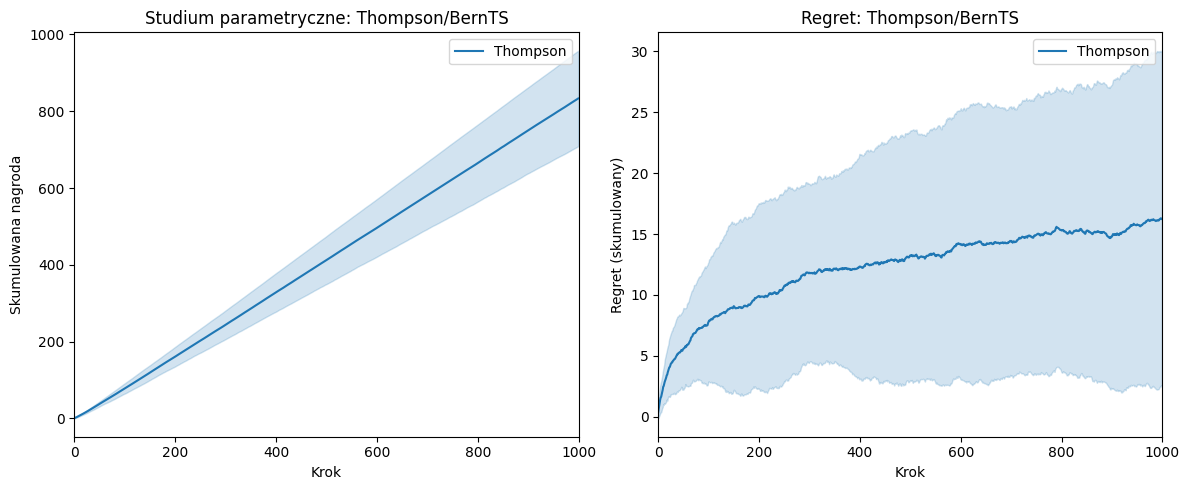

In [12]:
# C: studium parametryczne
run_parameter_study(
    time_steps=TIME_STEPS,
    n_trials=TRIALS_PER_LEARNER,
    k_arms=K_ARMS_RANDOM,
    seed=SEED,
)
plt.close("all")

## Eksperyment D — bandyta niestacjonarny (dryf)

Start od `POTENTIAL_HITS`; w każdym kroku niewielkie przesunięcia $\mathcal{N}(0,\sigma^2)$ (tu $\sigma=0.01$). Dla tych samych `seed` + `trial` wszyscy uczniowie widzą identyczny ciąg dryfu. Zachłanny krok z **stalym** $\alpha$ szybciej goni zmiany niż w pełni wygładzająca średnia próbkowa.


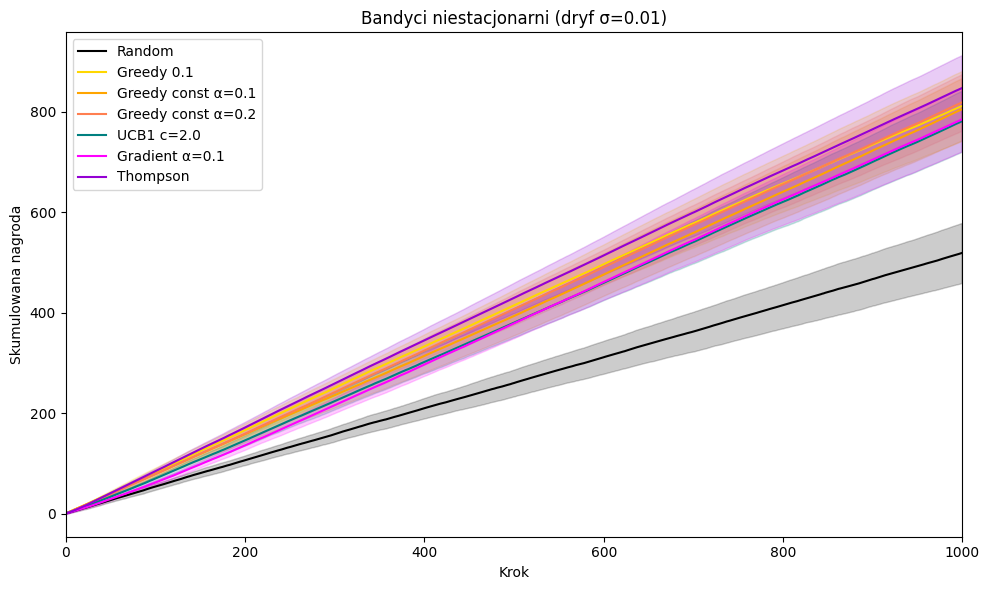

In [13]:
# D: dryf
run_nonstationary_experiment(
    learners=[
        RandomLearner(),
        GreedyLearner(0.1, color="gold"),
        GreedyConstantStepLearner(epsilon=0.1, alpha=0.1, color="orange"),
        GreedyConstantStepLearner(epsilon=0.1, alpha=0.2, color="coral"),
        UCB1(c=2.0, color="teal"),
        GradientBanditLearner(alpha=0.1, color="magenta"),
        ThompsonSamplingLearner(color="darkviolet"),
    ],
    initial_probs=dict(POTENTIAL_HITS),
    time_steps=TIME_STEPS,
    n_trials=TRIALS_PER_LEARNER,
    drift_std=0.01,
    seed=SEED,
)
plt.close()

## Eksperyment E — słupki: skumulowany regret w ostatnim kroku $R(T)$

**E.1 (czułość parametrów)** Dla tych samych siatek co w `run_parameter_study` liczymy uśredniony `mean_regret[-1]` z `evaluate_learner_random_problems` (ten sam `seed` dla wszystkich) — szybki odczyt, które **m, ε, c, α** kończą z niższym $R(T)$ przy losowanych $p_a$.

**E.2 (kontekst Thompsona)** Pojedynczy słupek „tylko Thompson” był trudny do odczytu, bo brak wspólnej skali. Drugi wykres zestawia **kilka reprezentatywnych polityk** (m.in. ten sam *Thompson* z Beta(1,1) co w `bandits.py`) z baseline’ami (Random, ETC, …) — wszystkie na **tych samych 50 instancjach** losowego problemu, więc można sensownie porównać **Thompson vs UCB, gradient, ε-greedy** po $T=1000$ krokach.


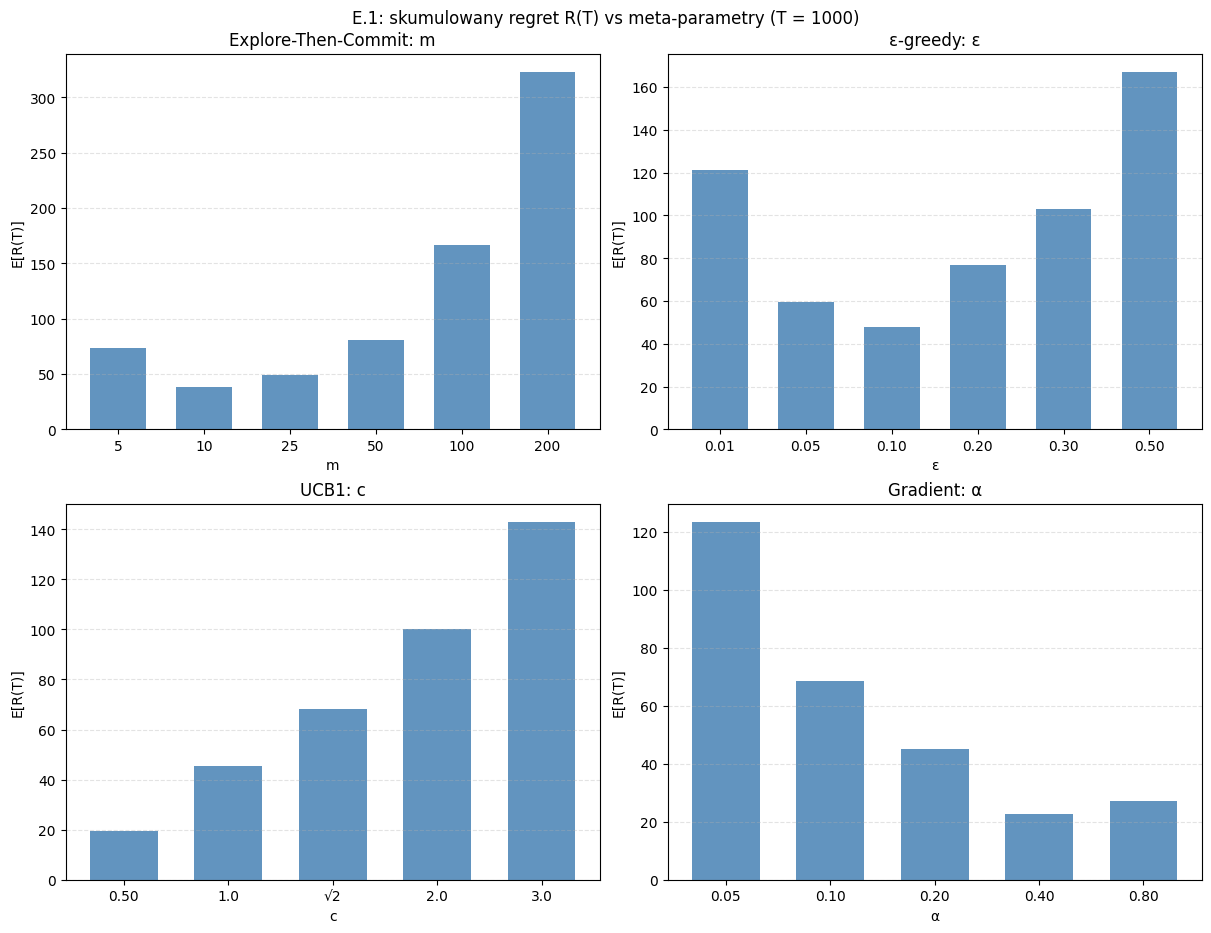

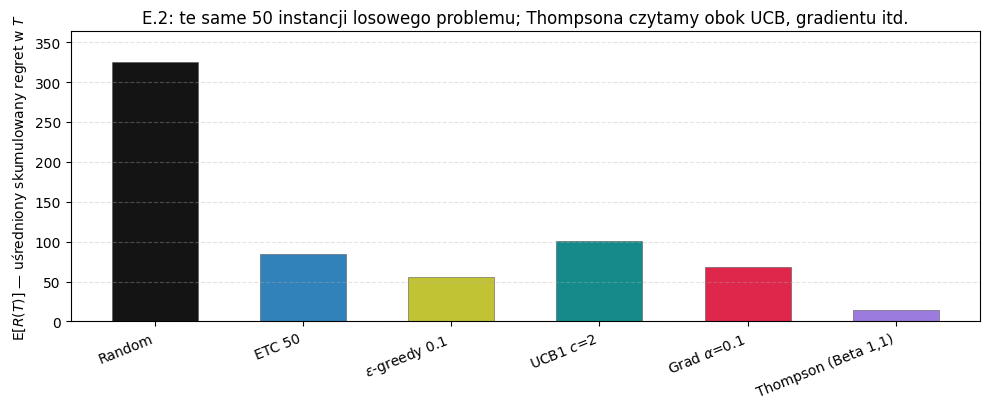

In [14]:
# E.1 + E.2: regret R(T) — czułość parametrów oraz porównanie metod (w tym Thompson)
SQ2 = float(np.sqrt(2))
configs = [
    (
        "Explore-Then-Commit: m",
        "m",
        [5, 10, 25, 50, 100, 200],
        [ExploreThenCommitLearner(m=m, color="C0") for m in [5, 10, 25, 50, 100, 200]],
    ),
    (
        "ε-greedy: ε",
        "ε",
        [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
        [GreedyLearner(epsilon=e, color="C0") for e in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]],
    ),
    (
        "UCB1: c",
        "c",
        [0.5, 1.0, SQ2, 2.0, 3.0],
        [UCB1(c=c, color="C0") for c in [0.5, 1.0, SQ2, 2.0, 3.0]],
    ),
    (
        "Gradient: α",
        "α",
        [0.05, 0.1, 0.2, 0.4, 0.8],
        [GradientBanditLearner(alpha=a, color="C0") for a in [0.05, 0.1, 0.2, 0.4, 0.8]],
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes_flat = list(axes.ravel())
for ax, (title, label, xvals, l_list) in zip(axes_flat, configs):
    regrets: list[float] = []
    for L in l_list:
        _, _, mean_reg, _ = evaluate_learner_random_problems(
            L, n_trials=TRIALS_PER_LEARNER, time_steps=TIME_STEPS, k_arms=K_ARMS_RANDOM, seed=SEED
        )
        regrets.append(float(mean_reg[-1]))

    def _lab(v):
        if isinstance(v, float) and abs(v - SQ2) < 1e-9:
            return "√2"
        if isinstance(v, float) and v != int(v):
            return f"{v:.2f}"
        return str(v)

    x_labs = [_lab(v) for v in xvals]
    ax.bar(x_labs, regrets, color="steelblue", alpha=0.85, width=0.65)
    ax.set_xlabel(label)
    ax.set_ylabel("E[R(T)]")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

fig.suptitle("E.1: skumulowany regret R(T) vs meta-parametry (T = %d)" % TIME_STEPS, fontsize=12, y=1.02)
plt.show()
plt.close(fig)

# Wspólna skala: te same instancje (seed) dla każdej etykiety
compare = [
    ("Random", RandomLearner()),
    ("ETC 50", ExploreThenCommitLearner(50, color="tab:blue")),
    (r"$\varepsilon$-greedy 0.1", GreedyLearner(0.1, color="tab:olive")),
    (r"UCB1 $c$=2", UCB1(c=2.0, color="teal")),
    (r"Grad $\alpha$=0.1", GradientBanditLearner(alpha=0.1, color="crimson")),
    ("Thompson (Beta 1,1)", ThompsonSamplingLearner(color="mediumpurple")),
]
names, regs, cols = [], [], []
for name, L in compare:
    _, _, mean_reg, _ = evaluate_learner_random_problems(
        L, n_trials=TRIALS_PER_LEARNER, time_steps=TIME_STEPS, k_arms=K_ARMS_RANDOM, seed=SEED
    )
    names.append(name)
    regs.append(float(mean_reg[-1]))
    cols.append(L.color)

x = np.arange(len(names))
fig2, ax2 = plt.subplots(figsize=(10, 4.2))
ax2.bar(x, regs, color=cols, width=0.58, edgecolor="0.3", linewidth=0.4, alpha=0.92)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=22, ha="right", fontsize=10)
ax2.set_ylabel(r"E[$R(T)$] — uśredniony skumulowany regret w $T$")
ax2.set_title("E.2: te same 50 instancji losowego problemu; Thompsona czytamy obok UCB, gradientu itd.")
m = max(regs) if max(regs) > 0 else 1.0
ax2.set_ylim(0, m * 1.12)
ax2.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()
plt.close("all")


## Podsumowanie

### Wnioski z wykresów
- **Stacjonarny bandyta, stałe `POTENTIAL_HITS` (A):** szybko widać przewagę strategii, które **uczą się** $Q(a)$ (UCB, sampling bayesowski, gradient) nad losowym. **Explore-then-commit** i **$\epsilon$-greedy** mocno zależą od długości fazy poznania, od $\varepsilon$, oraz od tego, czy w ogóle wystarczy horyzont, by wejść w późną, trwałą eksploatację.
- **Losowane prawdopodobieństwa, wspólny `seed` (B, C, E.1, E.2):** wyniki nie „przylepiają” się do jednej historii tytułów — wychodzi **regret** jako miara, które metody ograniczają stratę względem optymalnej polityki w danej instancji. W **E.1** widać, jak zmiana **m, ε, c, α** przesuwa **$R(T)$**. W **E.2** *Thompson* (ten sam *Beta(1,1)* co w `ThompsonSamplingLearner` w `bandits.py`) ma czytelną interpretację tylko **na wspólnej skali** z UCB, gradientem i baseline’ami — jeden słup bez kontekstu był mylący.
- **Bandyta z dryfem (D):** gdy **$p_a$** płyną, średnia próbkowa w zwykłym **Greedy** przestaje śledzić bieżące optimum; **stałokrokowa** aktualizacja $Q$ w `GreedyConstantStep` (parametr $\alpha$) szybciej goni zmiany — to odpowiada standardowej narracji o niestacjonarnym bandycie (por. wykład i [Bandyci](Bandyci.pdf)).

### Ograniczenia i czytanie wyników
- Wszystkie wykresy to **średnie po `TRIALS` powtórkach** (często z pasem zmiennosści); inny *seed* lub inna liczba ramion $K$ może zmienić ranking — wniosek ma być **względny** (typowo UCB/TS/gradient lepiej niż Random), nie o absolutnej wartości $R(T)$.
- **E.2** to jeden zestaw wariantów na czytelny wykres; pełne skany parametrów są w C i w siatce **E.1**. W **D** celowo nie rysujemy klasycznego regretu, bo w dryfie „najlepsze ramię” nie jest ustalone w czasie; interpretujemy **skumulowaną nagrodę** przy **wspólnym** dryfie między uczniami w trialu.

| Parametr | Wartość (w `bandits`, użyte w notatniku) |
|----------|------------------------------------------|
| `TIME_STEPS` (T) | 1000 |
| `TRIALS_PER_LEARNER` | 50 |
| `K_ARMS_RANDOM` | 5 |
| `SEED` (te same instancje problemów między uczniami) | 42 |
| `drift_std` (D) | 0.01 |